In [127]:
import pandas as pd

In [128]:
df=pd.read_csv("train.csv",usecols=["Age","Fare","Survived"])

In [129]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [130]:
df["Fare"].skew() # high right skewness

np.float64(4.787316519674893)

In [131]:
df["Age"].skew() # almost normal distribution

np.float64(0.38910778230082704)

In [132]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [133]:
# replacing missing values with mean
df["Age"].fillna(df["Age"].mean(),inplace=True)

/tmp/ipykernel_25146/1652023592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [134]:
df

,Survived,Age,Fare
0,0,22.000000,7.2500
1,1,38.000000,71.2833
2,1,26.000000,7.9250
3,1,35.000000,53.1000
4,0,35.000000,8.0500
...,...,...,...
886,0,27.000000,13.0000
887,1,19.000000,30.0000
888,0,29.699118,23.4500
889,1,26.000000,30.0000


In [135]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [136]:
# seperate input and output variable
x=df[["Age","Fare"]]
y=df[["Survived"]]

In [137]:
x

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [138]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [139]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [140]:
x_train

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


In [141]:
x_test

,Age,Fare
709,29.699118,15.2458
439,31.000000,10.5000
840,20.000000,7.9250
720,6.000000,33.0000
39,14.000000,11.2417
...,...,...
433,17.000000,7.1250
773,29.699118,7.2250
25,38.000000,31.3875
84,17.000000,10.5000


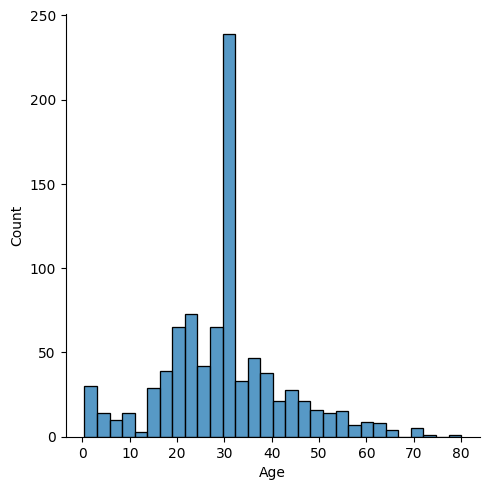

In [142]:
# checking for skewness
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.displot(df["Age"])


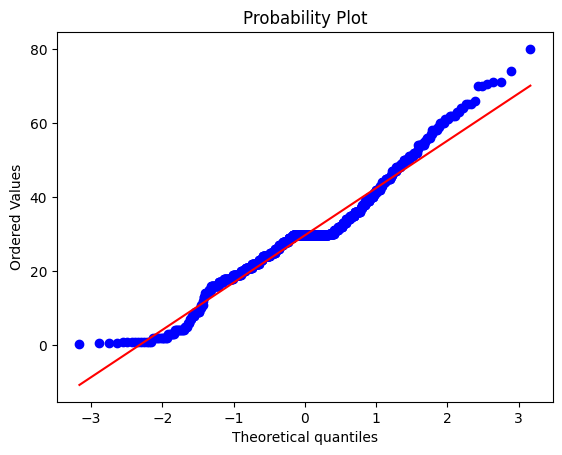

In [143]:
stats.probplot(df["Age"],dist="norm",plot=plt)
plt.show()

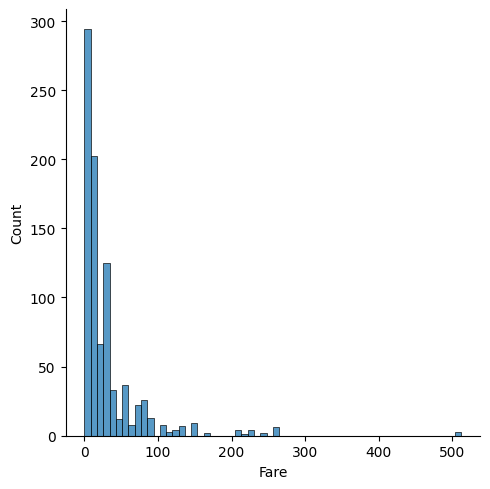

In [144]:
sns.displot(df["Fare"])

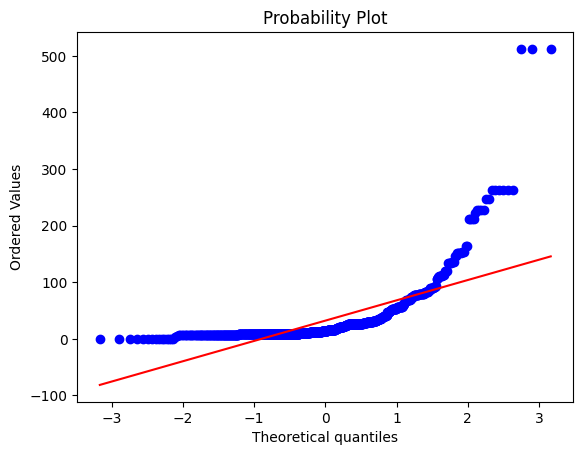

In [145]:
stats.probplot(df["Fare"],plot=plt)
plt.show()

In [146]:
# training model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

model1=LogisticRegression()
model1.fit(x_train,y_train)

/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [147]:
model2=DecisionTreeClassifier(random_state=42)
model2.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [148]:
y1_predict=model1.predict(x_test)

In [149]:
y2_predict=model2.predict(x_test)

In [150]:
# score
from sklearn.metrics import accuracy_score
score1=accuracy_score(y_test,y1_predict)
score2=accuracy_score(y_test,y2_predict)

In [151]:
score1

0.6480446927374302

In [152]:
score2

0.659217877094972

In [153]:
# now applying tranformation
import numpy as np
from sklearn.preprocessing import FunctionTransformer
transformer=FunctionTransformer(func=np.log1p)

x_train_transformed=transformer.fit_transform(x_train)
x_test_transformed=transformer.transform(x_test)

In [154]:
x_train_transformed

,Age,Fare
331,3.839452,3.384390
733,3.178054,2.639057
382,3.496508,2.188856
704,3.295837,2.180892
813,1.945910,3.474293
...,...,...
106,3.091042,2.157559
270,3.424234,3.465736
860,3.737670,2.715244
435,2.708050,4.795791


In [155]:
x_train_transformed.skew()

Age    -2.244631
Fare    0.403554
dtype: float64

In [156]:
model1=LogisticRegression()
model2=DecisionTreeClassifier(random_state=42)
model1.fit(x_train_transformed,y_train)
model2.fit(x_train_transformed,y_train)

/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [157]:
y1_predict=model1.predict(x_test_transformed)
y2_predict=model2.predict(x_test_transformed)

In [158]:
score1=accuracy_score(y_test,y1_predict)
score1=accuracy_score(y_test,y2_predict)

In [159]:
score1 # accuracy of linear reg model has been increased after applying transformation

0.664804469273743

In [160]:
score2 #no significant change in accuracy of decision tree model  after applying transformation

0.659217877094972

In [161]:
# cross validation 
from sklearn.model_selection import cross_val_score
import numpy
np.mean(cross_val_score(LogisticRegression(),x_train_transformed,y_train))


/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-v

np.float64(0.679661183886536)

In [162]:
np.mean(cross_val_score(DecisionTreeClassifier(),x_train_transformed,y_train,cv=5))

np.float64(0.6165960799763617)

((array([-3.09833772e+00, -2.82529557e+00, -2.67239243e+00, -2.56428702e+00,
         -2.47977990e+00, -2.40996845e+00, -2.35023723e+00, -2.29787334e+00,
         -2.25114194e+00, -2.20886405e+00, -2.17020067e+00, -2.13453273e+00,
         -2.10138998e+00, -2.07040647e+00, -2.04129166e+00, -2.01381086e+00,
         -1.98777170e+00, -1.96301446e+00, -1.93940499e+00, -1.91682952e+00,
         -1.89519069e+00, -1.87440451e+00, -1.85439799e+00, -1.83510731e+00,
         -1.81647630e+00, -1.79845528e+00, -1.78100007e+00, -1.76407122e+00,
         -1.74763334e+00, -1.73165455e+00, -1.71610603e+00, -1.70096166e+00,
         -1.68619765e+00, -1.67179230e+00, -1.65772574e+00, -1.64397975e+00,
         -1.63053756e+00, -1.61738369e+00, -1.60450386e+00, -1.59188484e+00,
         -1.57951433e+00, -1.56738092e+00, -1.55547396e+00, -1.54378354e+00,
         -1.53230037e+00, -1.52101577e+00, -1.50992160e+00, -1.49901023e+00,
         -1.48827446e+00, -1.47770753e+00, -1.46730308e+00, -1.45705508e+00,

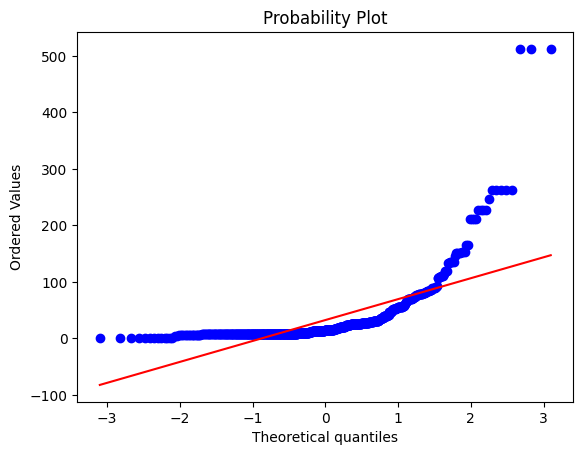

In [163]:
stats.probplot(x_train["Fare"],dist="norm",plot=plt)

((array([-3.09833772e+00, -2.82529557e+00, -2.67239243e+00, -2.56428702e+00,
         -2.47977990e+00, -2.40996845e+00, -2.35023723e+00, -2.29787334e+00,
         -2.25114194e+00, -2.20886405e+00, -2.17020067e+00, -2.13453273e+00,
         -2.10138998e+00, -2.07040647e+00, -2.04129166e+00, -2.01381086e+00,
         -1.98777170e+00, -1.96301446e+00, -1.93940499e+00, -1.91682952e+00,
         -1.89519069e+00, -1.87440451e+00, -1.85439799e+00, -1.83510731e+00,
         -1.81647630e+00, -1.79845528e+00, -1.78100007e+00, -1.76407122e+00,
         -1.74763334e+00, -1.73165455e+00, -1.71610603e+00, -1.70096166e+00,
         -1.68619765e+00, -1.67179230e+00, -1.65772574e+00, -1.64397975e+00,
         -1.63053756e+00, -1.61738369e+00, -1.60450386e+00, -1.59188484e+00,
         -1.57951433e+00, -1.56738092e+00, -1.55547396e+00, -1.54378354e+00,
         -1.53230037e+00, -1.52101577e+00, -1.50992160e+00, -1.49901023e+00,
         -1.48827446e+00, -1.47770753e+00, -1.46730308e+00, -1.45705508e+00,

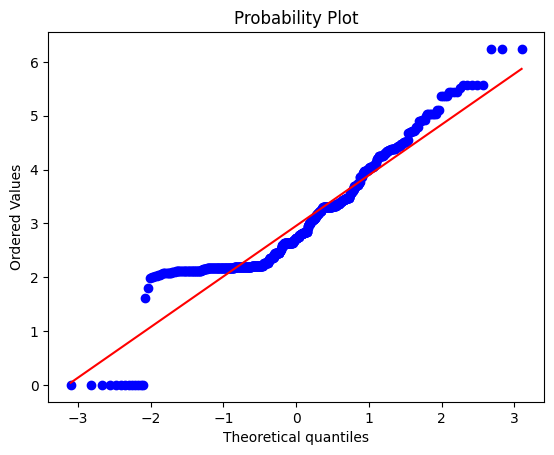

In [164]:
stats.probplot(x_train_transformed["Fare"],dist="norm",plot=plt)

((array([-3.09833772e+00, -2.82529557e+00, -2.67239243e+00, -2.56428702e+00,
         -2.47977990e+00, -2.40996845e+00, -2.35023723e+00, -2.29787334e+00,
         -2.25114194e+00, -2.20886405e+00, -2.17020067e+00, -2.13453273e+00,
         -2.10138998e+00, -2.07040647e+00, -2.04129166e+00, -2.01381086e+00,
         -1.98777170e+00, -1.96301446e+00, -1.93940499e+00, -1.91682952e+00,
         -1.89519069e+00, -1.87440451e+00, -1.85439799e+00, -1.83510731e+00,
         -1.81647630e+00, -1.79845528e+00, -1.78100007e+00, -1.76407122e+00,
         -1.74763334e+00, -1.73165455e+00, -1.71610603e+00, -1.70096166e+00,
         -1.68619765e+00, -1.67179230e+00, -1.65772574e+00, -1.64397975e+00,
         -1.63053756e+00, -1.61738369e+00, -1.60450386e+00, -1.59188484e+00,
         -1.57951433e+00, -1.56738092e+00, -1.55547396e+00, -1.54378354e+00,
         -1.53230037e+00, -1.52101577e+00, -1.50992160e+00, -1.49901023e+00,
         -1.48827446e+00, -1.47770753e+00, -1.46730308e+00, -1.45705508e+00,

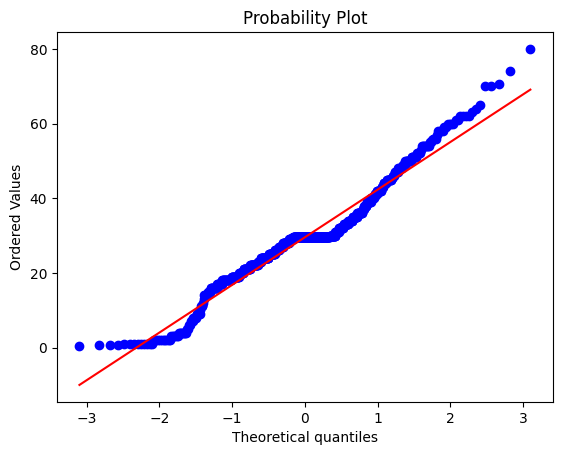

In [165]:
stats.probplot(x_train["Age"],dist="norm",plot=plt)

'\n\nafter applying transformation on age , graph became more skewed so no need to apply \ntransformation on age column.\n\n'

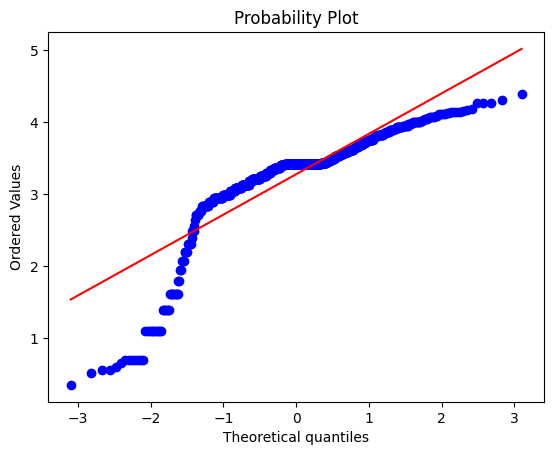

In [166]:
stats.probplot(x_train_transformed["Age"],dist="norm",plot=plt)
'''

after applying transformation on age , graph became more skewed so no need to apply 
transformation on age column.

'''

In [167]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression

def apply_transform(transform):

    x_train, x_test, y_train, y_test = train_test_split(
        x, y,
        test_size=0.2,
        random_state=42
    )

    transformer = ColumnTransformer(
        transformers=[
            ("custom_transformer",
             FunctionTransformer(transform),
             ["Fare"])
        ],
        remainder="passthrough"
    )

    pipeline = Pipeline([
        ("transformer", transformer),
        ("model", LogisticRegression())
    ])

    plt.Figure((200,200))
    stats.probplot(x_train["Fare"], dist="norm", plot=plt)
    plt.title("original fare")

    plt.show()

    plt.Figure((200,200))
    stats.probplot(
    transformer.fit_transform(x_train)[:,0],
    dist="norm",
    plot=plt)
    plt.title("transformed fare")
    plt.show()


    score = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5
    ).mean()

    print(score)

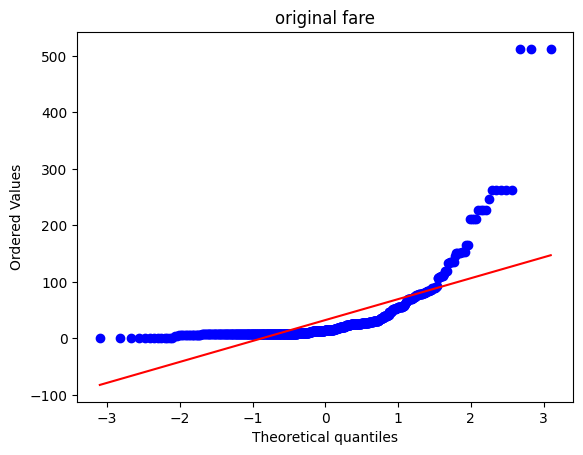

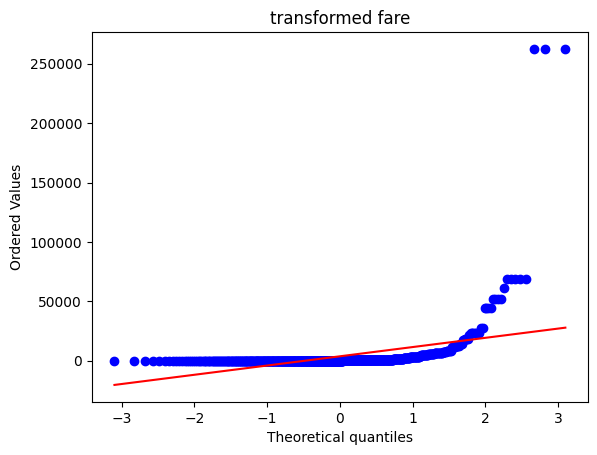

/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-v

0.6460652024032305


/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [168]:
apply_transform(lambda x:x**2)

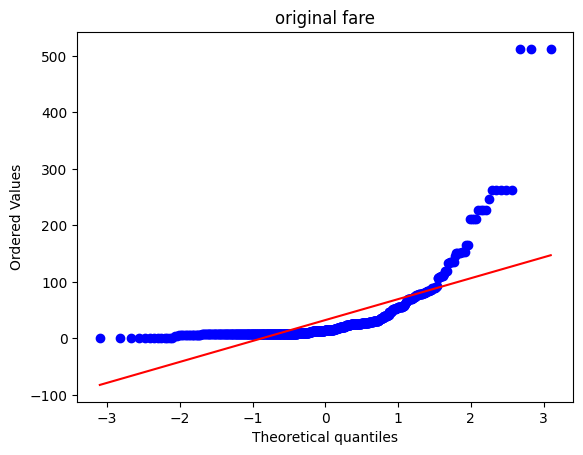

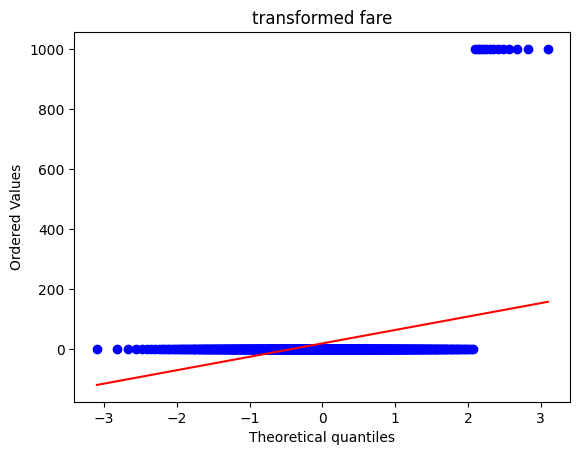

/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sundramkumar/Learning ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-v

0.6235989362749926


In [171]:
apply_transform(lambda x:1/(x+0.001))